# Day 7: Capstone Project

# - Problem selection

# - Data collection and preprocessing

# - Model development and evaluation

# - Basic Deployment using Streamlit

# Project - Medical Insurance Cost Predictor

# Import the necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Load Data

In [ ]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

In [ ]:
print("Data loaded from URL")
print(f"Shape: {df.shape}")

Data loaded from URL
Shape: (1338, 7)


In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
print("\nFirst 10 rows:")
print('\n')
df.head(10)


First 10 rows:




,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


# Explore the Data

In [ ]:
print("\nDataset info:")
print('\n')
df.info()


Dataset info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
print("\nDescriptive statistics:")
df.describe()


Descriptive statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# Check missing values
print("\nMissing values per column:")
print('\n')
df.isnull().sum()


Missing values per column:




,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# Visualisation

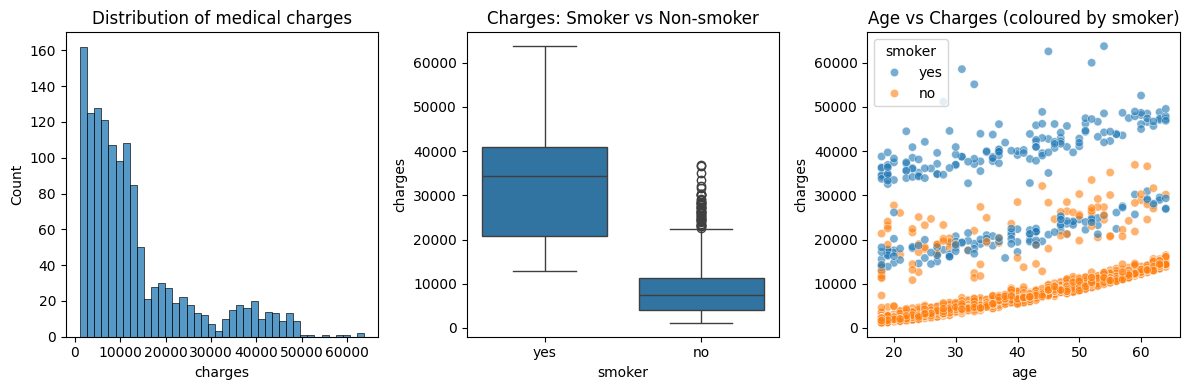

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['charges'], bins=40)
plt.title("Distribution of medical charges")

plt.subplot(1, 3, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges: Smoker vs Non‑smoker")

plt.subplot(1, 3, 3)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title("Age vs Charges (coloured by smoker)")

plt.tight_layout()
plt.show()

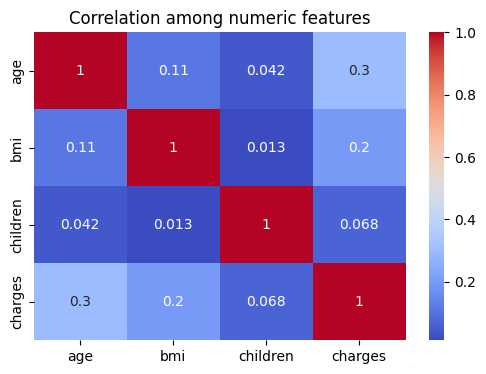

In [ ]:
# Correlation heatmap (numeric only)
numeric_cols = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation among numeric features")
plt.show()

# Data Preprocessing

In [ ]:
# Convert yes/no to binary
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [ ]:
# Check Number of regions
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
# One‑hot encode 'region' (creates 3 dummy columns)

if 'region' in df.columns:
    df = pd.get_dummies(df, columns=['region'], drop_first=True)
else:
    print("'region' already encoded or not present. Skipping.")

# This Checks if 'region' is still a column before encoding

In [ ]:
print("After encoding categorical variables:\n")
df.head()

After encoding categorical variables:



,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


# Train‑test split

In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 1070 rows
Test set size: 268 rows


# Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

In [ ]:
print("LINEAR REGRESSION")
print(f"RMSE: ${rmse_lr:.0f}")
print(f"R² score: {r2_lr:.3f}")

LINEAR REGRESSION
RMSE: $5796
R² score: 0.784


# Random Forest for Regression

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_reg.predict(X_test)

In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [ ]:
print("RANDOM FOREST REGRESSOR")
print(f"RMSE: ${rmse_rf:.0f}")
print(f"R² score: {r2_rf:.3f}")

RANDOM FOREST REGRESSOR
RMSE: $4578
R² score: 0.865


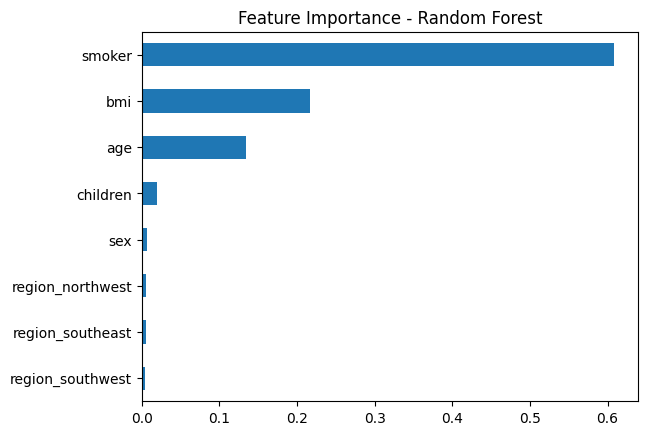

In [ ]:
# Feature importance
importance = pd.Series(rf_reg.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
print("\nMost important feature:", importance.idxmax(), "with importance", round(importance.max(), 3))


Most important feature: smoker with importance 0.609


# Saving the Model

In [ ]:
import joblib

# Save the Random Forest Regressor
joblib.dump(rf_reg, 'model.pkl')

# Also save the list of feature columns (important for the app)
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!
